Imports

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from google.colab import drive

Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Face Detector (Viola-Jones)

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

Shared Functions (Used for BOTH datasets)

Function: Loading Datasets

In [ ]:
def load_and_detect_faces(folder_path, use_whole_image_if_no_face=True):
    images, labels = [], []

    if not os.path.exists(folder_path):
        print(f"Error: Path not found: {folder_path}")
        return images, labels

    classes = [c for c in os.listdir(folder_path) if not c.startswith('.')]
    print(f"Scanning {folder_path} | Classes: {classes}")

    for label in classes:
        label_path = os.path.join(folder_path, label)
        if not os.path.isdir(label_path):
            continue

        for file in os.listdir(label_path):
            img_path = os.path.join(label_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            faces = face_cascade.detectMultiScale(img, 1.1, 5, minSize=(30, 30))
            if len(faces) == 0 and use_whole_image_if_no_face:
                face = img
                images.append(face)
                labels.append(label)
            else:
                for (x, y, w, h) in faces:
                    face = img[y:y+h, x:x+w]
                    images.append(face)
                    labels.append(label)

    print(f"Loaded {len(images)} face images")
    return images, labels

Function: HOG Feature Extraction

In [ ]:
def extract_hog_features(images):
    """
    Extracts Histogram of Oriented Gradients (HOG) features
    from a list of grayscale face images.
    """
    features = []
    for img in images:
        img_resized = cv2.resize(img, (64, 64))
        hog_feat = hog(
            img_resized,
            orientations=8,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feat)
    return np.array(features)

Function: Evaluation + Plots

In [ ]:
def print_classification_report_custom(y_true, y_pred, dataset_name, labels):
    print(f"\n--- {dataset_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=labels))


def plot_confusion_matrix_custom(y_true, y_pred, dataset_name, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f"Normalized Confusion Matrix - {dataset_name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

Function: Multi-Image Plot

In [ ]:
def plot_multiple_predictions(image_paths, model):
    """
    Displays predictions for multiple test images using a trained model.
    """
    fig, axes = plt.subplots(1, len(image_paths), figsize=(5 * len(image_paths), 5))
    if len(image_paths) == 1:
        axes = [axes]


    for i, path in enumerate(image_paths):
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 5)


        if len(faces) == 0:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i].set_title("No Face Detected")
            axes[i].axis('off')
            continue


        x, y, w, h = faces[0]
        face = cv2.resize(gray[y:y+h, x:x+w], (64, 64))
        features = hog(face, orientations=8,
                        pixels_per_cell=(8, 8),
                        cells_per_block=(2, 2),
                        block_norm='L2-Hys').reshape(1, -1)


        pred = model.predict(features)[0]
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, pred, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)


        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Predicted: {pred}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

CK+ Dataset Pipeline


===== CK+ DATASET =====
Scanning /content/drive/My Drive/CK_dataset/train | Classes: ['neutral', 'anger', 'fear', 'happy', 'surprise', 'sadness']
Loaded 341 face images
Scanning /content/drive/My Drive/CK_dataset/test | Classes: ['fear', 'surprise', 'anger', 'happy', 'sadness', 'neutral']
Loaded 144 face images

--- CK+ Test Set Evaluation ---
Accuracy: 62.50%
              precision    recall  f1-score   support

       anger       0.70      0.39      0.50        18
        fear       0.00      0.00      0.00         7
       happy       0.90      0.87      0.88        30
     neutral       0.41      0.69      0.52        36
     sadness       0.46      0.35      0.40        17
    surprise       0.84      0.72      0.78        36

    accuracy                           0.62       144
   macro avg       0.55      0.50      0.51       144
weighted avg       0.64      0.62      0.62       144



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


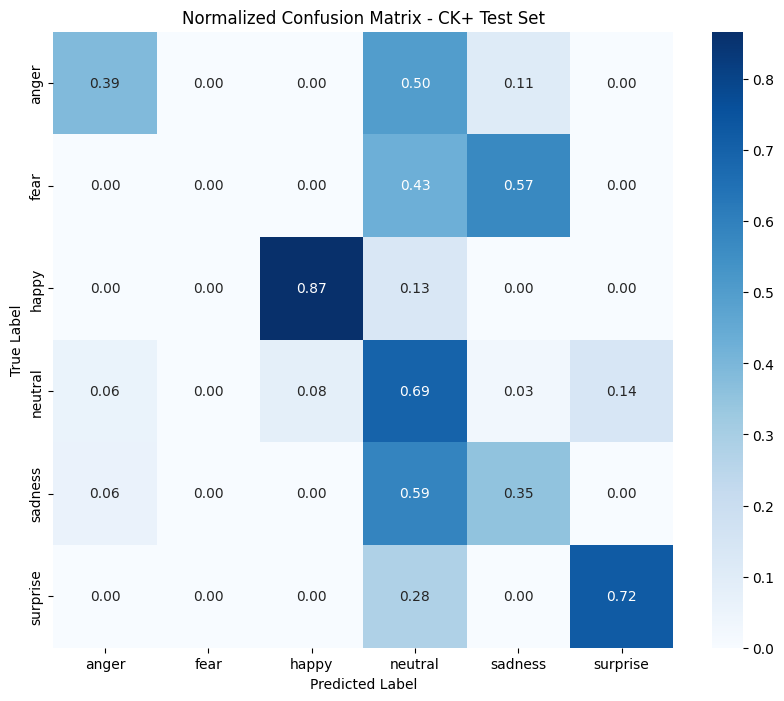

In [ ]:
print("\n===== CK+ DATASET =====")


TRAIN_FOLDER_CK = "/content/drive/My Drive/CK_dataset/train"
TEST_FOLDER_CK = "/content/drive/My Drive/CK_dataset/test"


X_train_faces_ck, y_train_ck = load_and_detect_faces(TRAIN_FOLDER_CK)
X_test_faces_ck, y_test_ck = load_and_detect_faces(TEST_FOLDER_CK)


EMOTION_LABELS_CK = sorted(list(set(y_train_ck + y_test_ck)))


X_train_features_ck = extract_hog_features(X_train_faces_ck)
X_test_features_ck = extract_hog_features(X_test_faces_ck)


svm_model_ck = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=7, gamma='scale', probability=True)
)


svm_model_ck.fit(X_train_features_ck, y_train_ck)


y_pred_ck = svm_model_ck.predict(X_test_features_ck)


print_classification_report_custom(y_test_ck, y_pred_ck, "CK+ Test Set", EMOTION_LABELS_CK)
plot_confusion_matrix_custom(y_test_ck, y_pred_ck, "CK+ Test Set", EMOTION_LABELS_CK)

JAFFE Dataset Pipeline


===== JAFFE DATASET =====
Scanning /content/drive/My Drive/JAFFE-[70,30]/train | Classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Surprise', 'Sad']
Loaded 128 face images
Scanning /content/drive/My Drive/JAFFE-[70,30]/test | Classes: ['Fear', 'Neutral', 'Happy', 'Angry', 'Sad', 'Surprise']
Loaded 55 face images

--- JAFFE Test Set Evaluation ---
Accuracy: 80.00%
              precision    recall  f1-score   support

       Angry       0.90      1.00      0.95         9
        Fear       0.50      0.90      0.64        10
       Happy       1.00      0.67      0.80         9
     Neutral       1.00      0.67      0.80         9
         Sad       0.89      0.89      0.89         9
    Surprise       1.00      0.67      0.80         9

    accuracy                           0.80        55
   macro avg       0.88      0.80      0.81        55
weighted avg       0.87      0.80      0.81        55



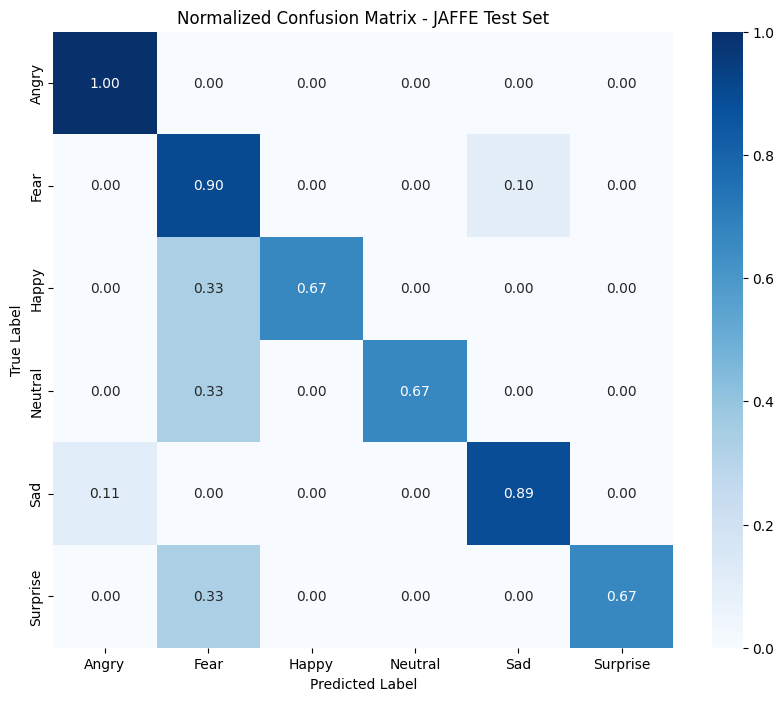

In [ ]:
print("\n===== JAFFE DATASET =====")


TRAIN_FOLDER_JAFFE = "/content/drive/My Drive/JAFFE-[70,30]/train"
TEST_FOLDER_JAFFE = "/content/drive/My Drive/JAFFE-[70,30]/test"


X_train_faces_jaffe, y_train_jaffe = load_and_detect_faces(TRAIN_FOLDER_JAFFE)
X_test_faces_jaffe, y_test_jaffe = load_and_detect_faces(TEST_FOLDER_JAFFE)


EMOTION_LABELS_JAFFE = sorted(list(set(y_train_jaffe + y_test_jaffe)))


X_train_features_jaffe = extract_hog_features(X_train_faces_jaffe)
X_test_features_jaffe = extract_hog_features(X_test_faces_jaffe)


svm_model_jaffe = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=7, gamma='scale', probability=True)
)


svm_model_jaffe.fit(X_train_features_jaffe, y_train_jaffe)


y_pred_jaffe = svm_model_jaffe.predict(X_test_features_jaffe)


print_classification_report_custom(y_test_jaffe, y_pred_jaffe, "JAFFE Test Set", EMOTION_LABELS_JAFFE)
plot_confusion_matrix_custom(y_test_jaffe, y_pred_jaffe, "JAFFE Test Set", EMOTION_LABELS_JAFFE)

Mapping CK+ and JAFFE emotion Labels

In [ ]:
# Emotion label mapping: CK+ → JAFFE
EMOTION_MAP = {
    "anger": "Angry",
    "fear": "Fear",
    "happy": "Happy",
    "neutral": "Neutral",
    "sadness": "Sad",       # CK+ uses "sadness", JAFFE uses "Sad"
    "surprise": "Surprise"
}

Comparison of CK+ and JAFFE test Predictions

In [ ]:
def get_mapped_example_images(test_ck, test_jaffe, emotion_map):
    """
    Collect one image path per emotion from both CK+ and JAFFE using mapped labels.
    Returns two lists: CK+ image paths, JAFFE image paths.
    """
    ck_paths, jaffe_paths = [], []
    for ck_label, jaffe_label in emotion_map.items():
        ck_folder = os.path.join(test_ck, ck_label)
        jaffe_folder = os.path.join(test_jaffe, jaffe_label)

        # Get CK+ image
        ck_file = next((f for f in os.listdir(ck_folder) if not f.startswith('.')), None) if os.path.exists(ck_folder) else None
        if ck_file:
            ck_paths.append(os.path.join(ck_folder, ck_file))

        # Get JAFFE image
        jaffe_file = next((f for f in os.listdir(jaffe_folder) if not f.startswith('.')), None) if os.path.exists(jaffe_folder) else None
        if jaffe_file:
            jaffe_paths.append(os.path.join(jaffe_folder, jaffe_file))

    return ck_paths, jaffe_paths

def show_mapped_comparison(model_ck, test_ck, model_jaffe, test_jaffe, emotion_map):
    """
    Show CK+ predictions in row 1 and JAFFE predictions in row 2 using mapped emotion labels.
    """
    ck_images, jaffe_images = get_mapped_example_images(test_ck, test_jaffe, emotion_map)
    num_emotions = min(len(ck_images), len(jaffe_images))

    fig, axes = plt.subplots(2, num_emotions, figsize=(5 * num_emotions, 10))

    # CK+ row
    for i, path in enumerate(ck_images[:num_emotions]):
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 5)
        face = cv2.resize(gray, (64, 64)) if len(faces) == 0 else cv2.resize(gray[faces[0][1]:faces[0][1]+faces[0][3], faces[0][0]:faces[0][0]+faces[0][2]], (64, 64))
        features = hog(face, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys').reshape(1, -1)
        pred = model_ck.predict(features)[0]
        axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"CK+: {pred}")
        axes[0, i].axis('off')

    # JAFFE row
    for i, path in enumerate(jaffe_images[:num_emotions]):
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 5)
        face = cv2.resize(gray, (64, 64)) if len(faces) == 0 else cv2.resize(gray[faces[0][1]:faces[0][1]+faces[0][3], faces[0][0]:faces[0][0]+faces[0][2]], (64, 64))
        features = hog(face, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys').reshape(1, -1)
        pred = model_jaffe.predict(features)[0]
        axes[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, i].set_title(f"JAFFE: {pred}")
        axes[1, i].axis('off')

    plt.suptitle("Comparison of CK+ and JAFFE Predictions", fontsize=16)
    plt.tight_layout()
    plt.show()

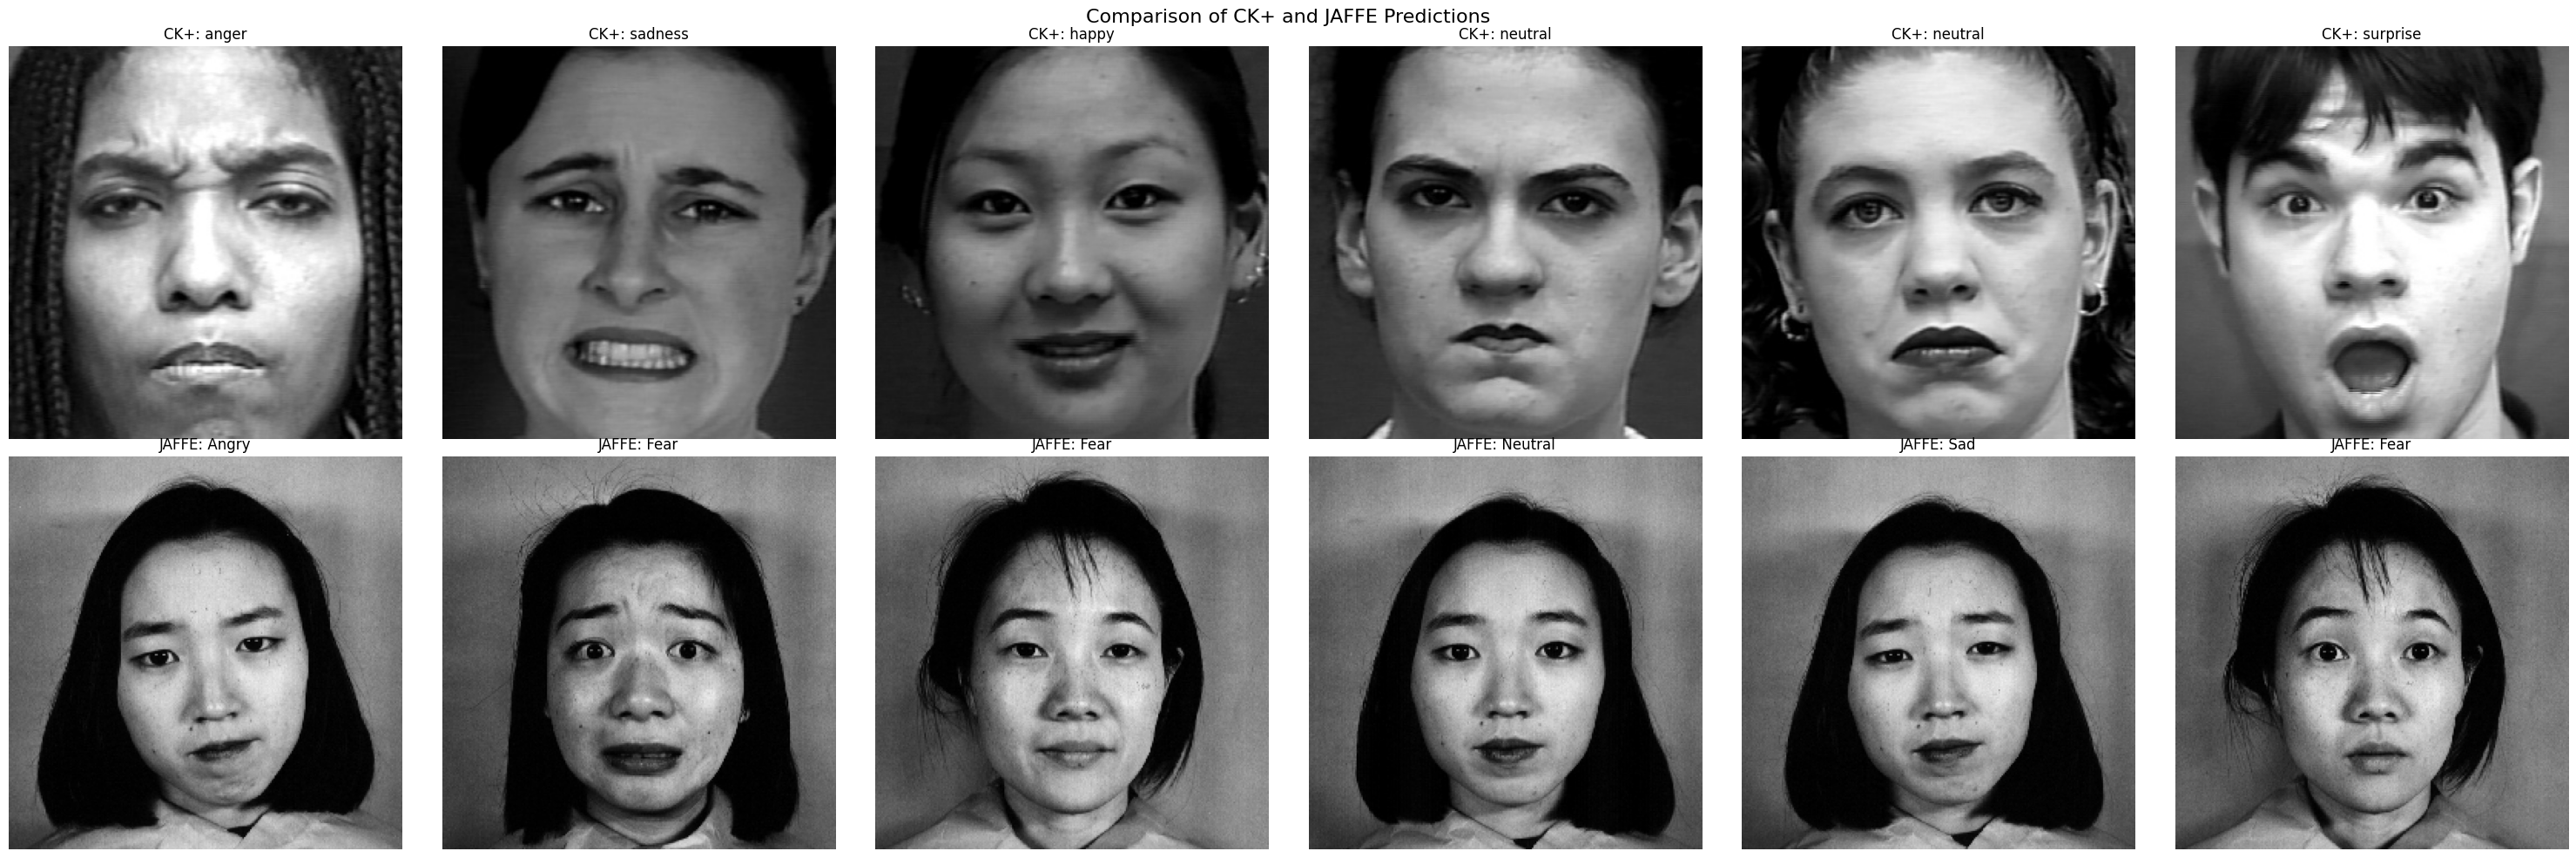

In [ ]:
show_mapped_comparison(svm_model_ck, TEST_FOLDER_CK,
                       svm_model_jaffe, TEST_FOLDER_JAFFE,
                       EMOTION_MAP)